# 05 — Avaliação do SAM 2 (Zero-Shot)

Testa o SAM 2 da Meta como modelo de segmentação **zero-shot** no ISIC 2018.

**Zero-shot** significa que o SAM 2 nunca foi treinado nesse dataset — ele segmenta
qualquer objeto a partir de um prompt visual (aqui usamos uma bounding box centrada).

Isso o torna diferente da U-Net e do DermoSegDiff, que foram treinados especificamente
em imagens de lesões. O resultado serve como baseline de comparação para entender
o quanto o treinamento supervisionado agrega.

**Pré-requisito:** SAM 2 instalado via `pip install -e .` no repositório da Meta.


## 1. Imports e Configuração


In [20]:
import sys
sys.path.insert(0, '..')

import torch
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
from skimage.transform import resize

from src.utils import load_image, show_comparison
from src.preprocessing import Pipeline
from src.models.sam2_inference import SAM2Segmenter

with open('../../config.yaml') as f:
    cfg = yaml.safe_load(f)

pipeline = Pipeline(cfg)
print('Pipeline carregado.')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Pipeline carregado.
Device: cuda


## 2. Carregar SAM 2

Ajuste `SAM2_CHECKPOINT` para o caminho do arquivo `.pt` que você baixou.
Para RTX 3050, use o `tiny` ou `small`.


In [21]:
# Ajuste para o caminho real do checkpoint na sua máquina
SAM2_CHECKPOINT = r'C:/Users/lucas/UFERSA/Computer_Science/IC/Segmentation/sam2/checkpoints/sam2.1_hiera_tiny.pt'
SAM2_CFG        = r'C:/Users/lucas/UFERSA/Computer_Science/IC/Segmentation/sam2/sam2/configs/sam2.1/sam2.1_hiera_t.yaml'

segmenter = SAM2Segmenter(
    model_cfg=SAM2_CFG,
    checkpoint_path=SAM2_CHECKPOINT,
    margin_ratio=0.10,
)


Carregando SAM 2 (C:/Users/lucas/UFERSA/Computer_Science/IC/Segmentation/sam2/sam2/configs/sam2.1/sam2.1_hiera_t.yaml) em: cuda
SAM 2 carregado.


## 3. Teste Visual em Uma Imagem

Valida que a segmentação está funcionando antes de rodar o dataset inteiro.


Dice:    0.8461
Jaccard: 0.7332


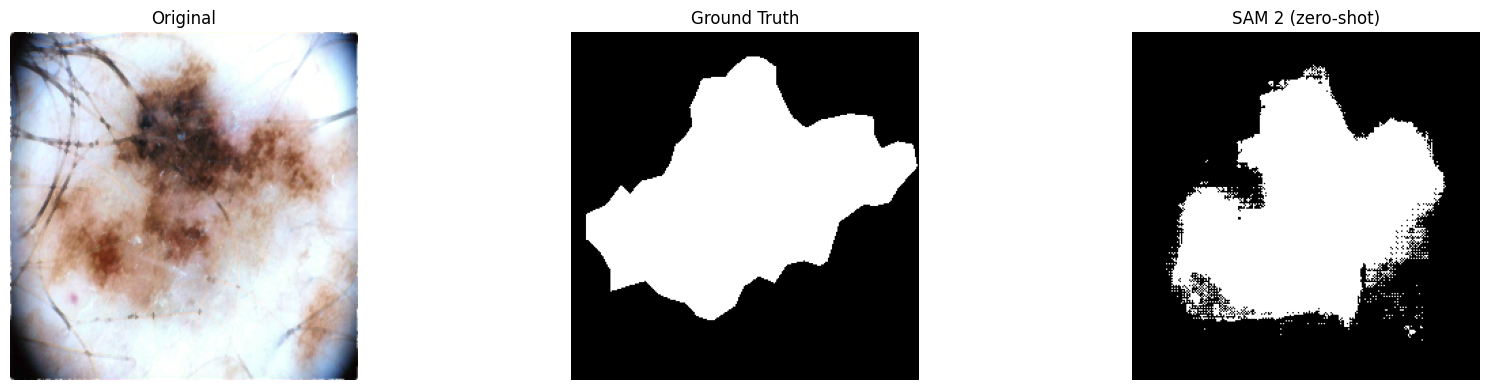

In [22]:
TEST_IMAGE = '../data/processed/training/images/ISIC_0000074.png'
TEST_MASK  = '../data/processed/training/masks/ISIC_0000074.png'

img_original = load_image(TEST_IMAGE)
mask_gt_raw  = load_image(TEST_MASK)

# Segmentação
mask_sam2 = segmenter.segment(img_original)

# Alinha ground truth
if mask_gt_raw.ndim == 3:
    mask_gt_raw = mask_gt_raw[..., 0]
mask_gt = resize(
    mask_gt_raw, mask_sam2.shape,
    order=0, preserve_range=True, anti_aliasing=False
).astype(np.uint8)

# Métricas rápidas
gt_bin   = (mask_gt   > 0).astype(np.uint8)
pred_bin = (mask_sam2 > 0).astype(np.uint8)
tp = (pred_bin & gt_bin).sum()
fp = (pred_bin & (1 - gt_bin)).sum()
fn = ((1 - pred_bin) & gt_bin).sum()
dice    = 2 * tp / (2 * tp + fp + fn + 1e-8)
jaccard = tp / (tp + fp + fn + 1e-8)
print(f'Dice:    {dice:.4f}')
print(f'Jaccard: {jaccard:.4f}')

show_comparison({
    'Original':          img_original,
    'Ground Truth':      mask_gt,
    'SAM 2 (zero-shot)': mask_sam2,
}, figsize=(18, 4))


## 4. Avaliação no Dataset de Teste

Roda o SAM 2 em todas as imagens de teste e calcula métricas por imagem.


In [25]:
INPUT_DIR  = Path('../data/processed/test/images')
GT_DIR     = Path('../data/processed/test/masks')
EXTENSIONS = ('.jpg', '.jpeg', '.png')

image_paths = sorted(p for p in INPUT_DIR.iterdir() if p.suffix.lower() in EXTENSIONS)
print(f'{len(image_paths)} imagens encontradas.')

rows = []
errors = []

for i, img_path in enumerate(tqdm(image_paths, desc='SAM 2')):
    stem      = img_path.stem
    mask_path = GT_DIR / f'{stem}.png'

    if not mask_path.exists():
        errors.append(stem)
        continue

    img      = load_image(str(img_path))
    mask_raw = load_image(str(mask_path))

    try:
        mask_pred = segmenter.segment(img)
    except Exception as e:
        errors.append(f'{stem}: {e}')
        continue

    # Alinha e binariza ground truth
    if mask_raw.ndim == 3:
        mask_raw = mask_raw[..., 0]
    gt = resize(mask_raw, mask_pred.shape,
                order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)
    gt_bin   = (gt        > 0).astype(np.uint8)
    pred_bin = (mask_pred > 0).astype(np.uint8)

    tp = (pred_bin & gt_bin).sum()
    fp = (pred_bin & (1 - gt_bin)).sum()
    fn = ((1 - pred_bin) & gt_bin).sum()
    tn = ((1 - pred_bin) & (1 - gt_bin)).sum()

    dice        = 2 * tp / (2 * tp + fp + fn + 1e-8)
    jaccard     = tp / (tp + fp + fn + 1e-8)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision   = tp / (tp + fp + 1e-8)
    recall      = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    rows.append({
        'image':       stem,
        'dice':        round(float(dice),        4),
        'jaccard':     round(float(jaccard),     4),
        'accuracy':    round(float(accuracy),    4),
        'precision':   round(float(precision),   4),
        'recall':      round(float(recall),      4),
        'specificity': round(float(specificity), 4),
    })

if errors:
    print(f'\nErros ({len(errors)}): {errors[:5]}')

df_sam2 = pd.DataFrame(rows)
df_sam2.to_csv('../results/metrics/sam2_test_results.csv', index=False)
print(f'\nResultados salvos. {len(df_sam2)} imagens avaliadas.')


1000 imagens encontradas.


SAM 2: 100%|██████████| 1000/1000 [03:20<00:00,  4.98it/s]


Resultados salvos. 1000 imagens avaliadas.


## 5. Resumo e Comparação com os Outros Modelos


SAM 2 — resultados no conjunto de teste:


,dice,jaccard,accuracy,precision,recall,specificity
mean,0.4879,0.3951,0.6284,0.4894,0.6930,0.6560
std,0.3418,0.3239,0.2732,0.3944,0.3263,0.3328



Tabela comparativa (médias):


,dice,jaccard,accuracy,recall,specificity
model,,,,,
SAM 2 (zero-shot),0.4879,0.3951,0.6284,0.6930,0.6560
U-Net,0.8757,0.7976,0.9286,0.9259,0.9488
U-net 5blocks,0.8704,0.7936,0.9280,0.8981,0.9639


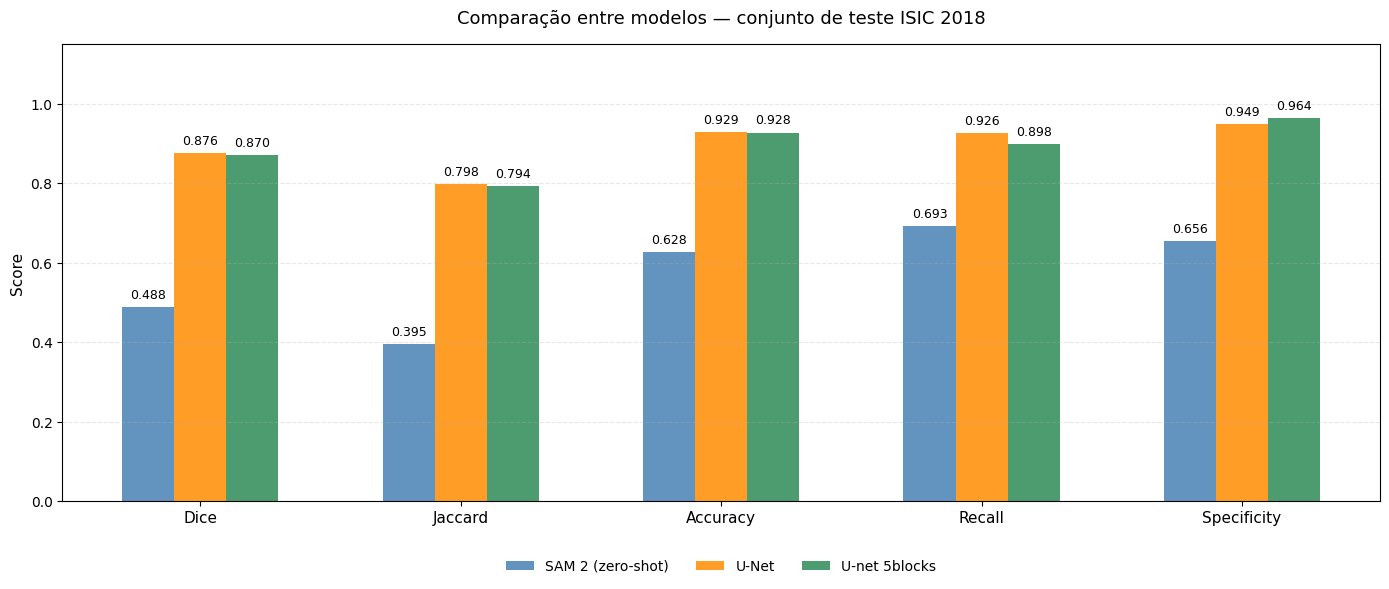

In [30]:
# Resumo SAM 2
summary_sam2 = df_sam2.drop(columns='image').agg(['mean', 'std']).round(4)
summary_sam2.to_csv('../results/metrics/sam2_summary.csv')
print('SAM 2 — resultados no conjunto de teste:')
display(summary_sam2)

# Tabela comparativa com todos os modelos
# Carrega CSVs dos outros modelos se existirem
comparison_rows = []

for model_name, csv_path in [
    ('SAM 2 (zero-shot)', '../results/metrics/sam2_summary.csv'),
    ('U-Net',             '../results/metrics/test_vanilla.csv'),
    ('U-net 5blocks',        '../results/metrics/test_5blocks.csv')
]:
    path = Path(csv_path)
    if path.exists():
        df = pd.read_csv(path, index_col=0)
        if 'mean' in df.index:
            row = df.loc['mean'].to_dict()
            row['model'] = model_name
            comparison_rows.append(row)

if comparison_rows:
    df_comparison = pd.DataFrame(comparison_rows).set_index('model')
    df_comparison = df_comparison[['dice', 'jaccard', 'accuracy', 'recall', 'specificity']]
    df_comparison.to_csv('../results/metrics/model_comparison.csv')
    print('\nTabela comparativa (médias):')
    display(df_comparison.round(4))

# Gráfico comparativo
if comparison_rows:
    metrics_plot = ['dice', 'jaccard', 'accuracy', 'recall', 'specificity']
    x = np.arange(len(metrics_plot))
    width = 0.20
    colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

    fig, ax = plt.subplots(figsize=(14, 6))
    for idx, (_, row) in enumerate(df_comparison.iterrows()):
        offset = (idx - len(df_comparison) / 2 + 0.5) * width
        bars = ax.bar(x + offset, [row[m] for m in metrics_plot],
                      width, label=row.name, color=colors[idx], alpha=0.85)
        ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in metrics_plot], fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Comparação entre modelos — conjunto de teste ISIC 2018', fontsize=13, pad=15)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(df_comparison), frameon=False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('../results/figures/model_comparison.png', dpi=150)
    plt.show()


## 6. Análise Qualitativa — Comparação Visual

Mostra exemplos lado a lado para entender onde o SAM 2 acerta e onde falha.


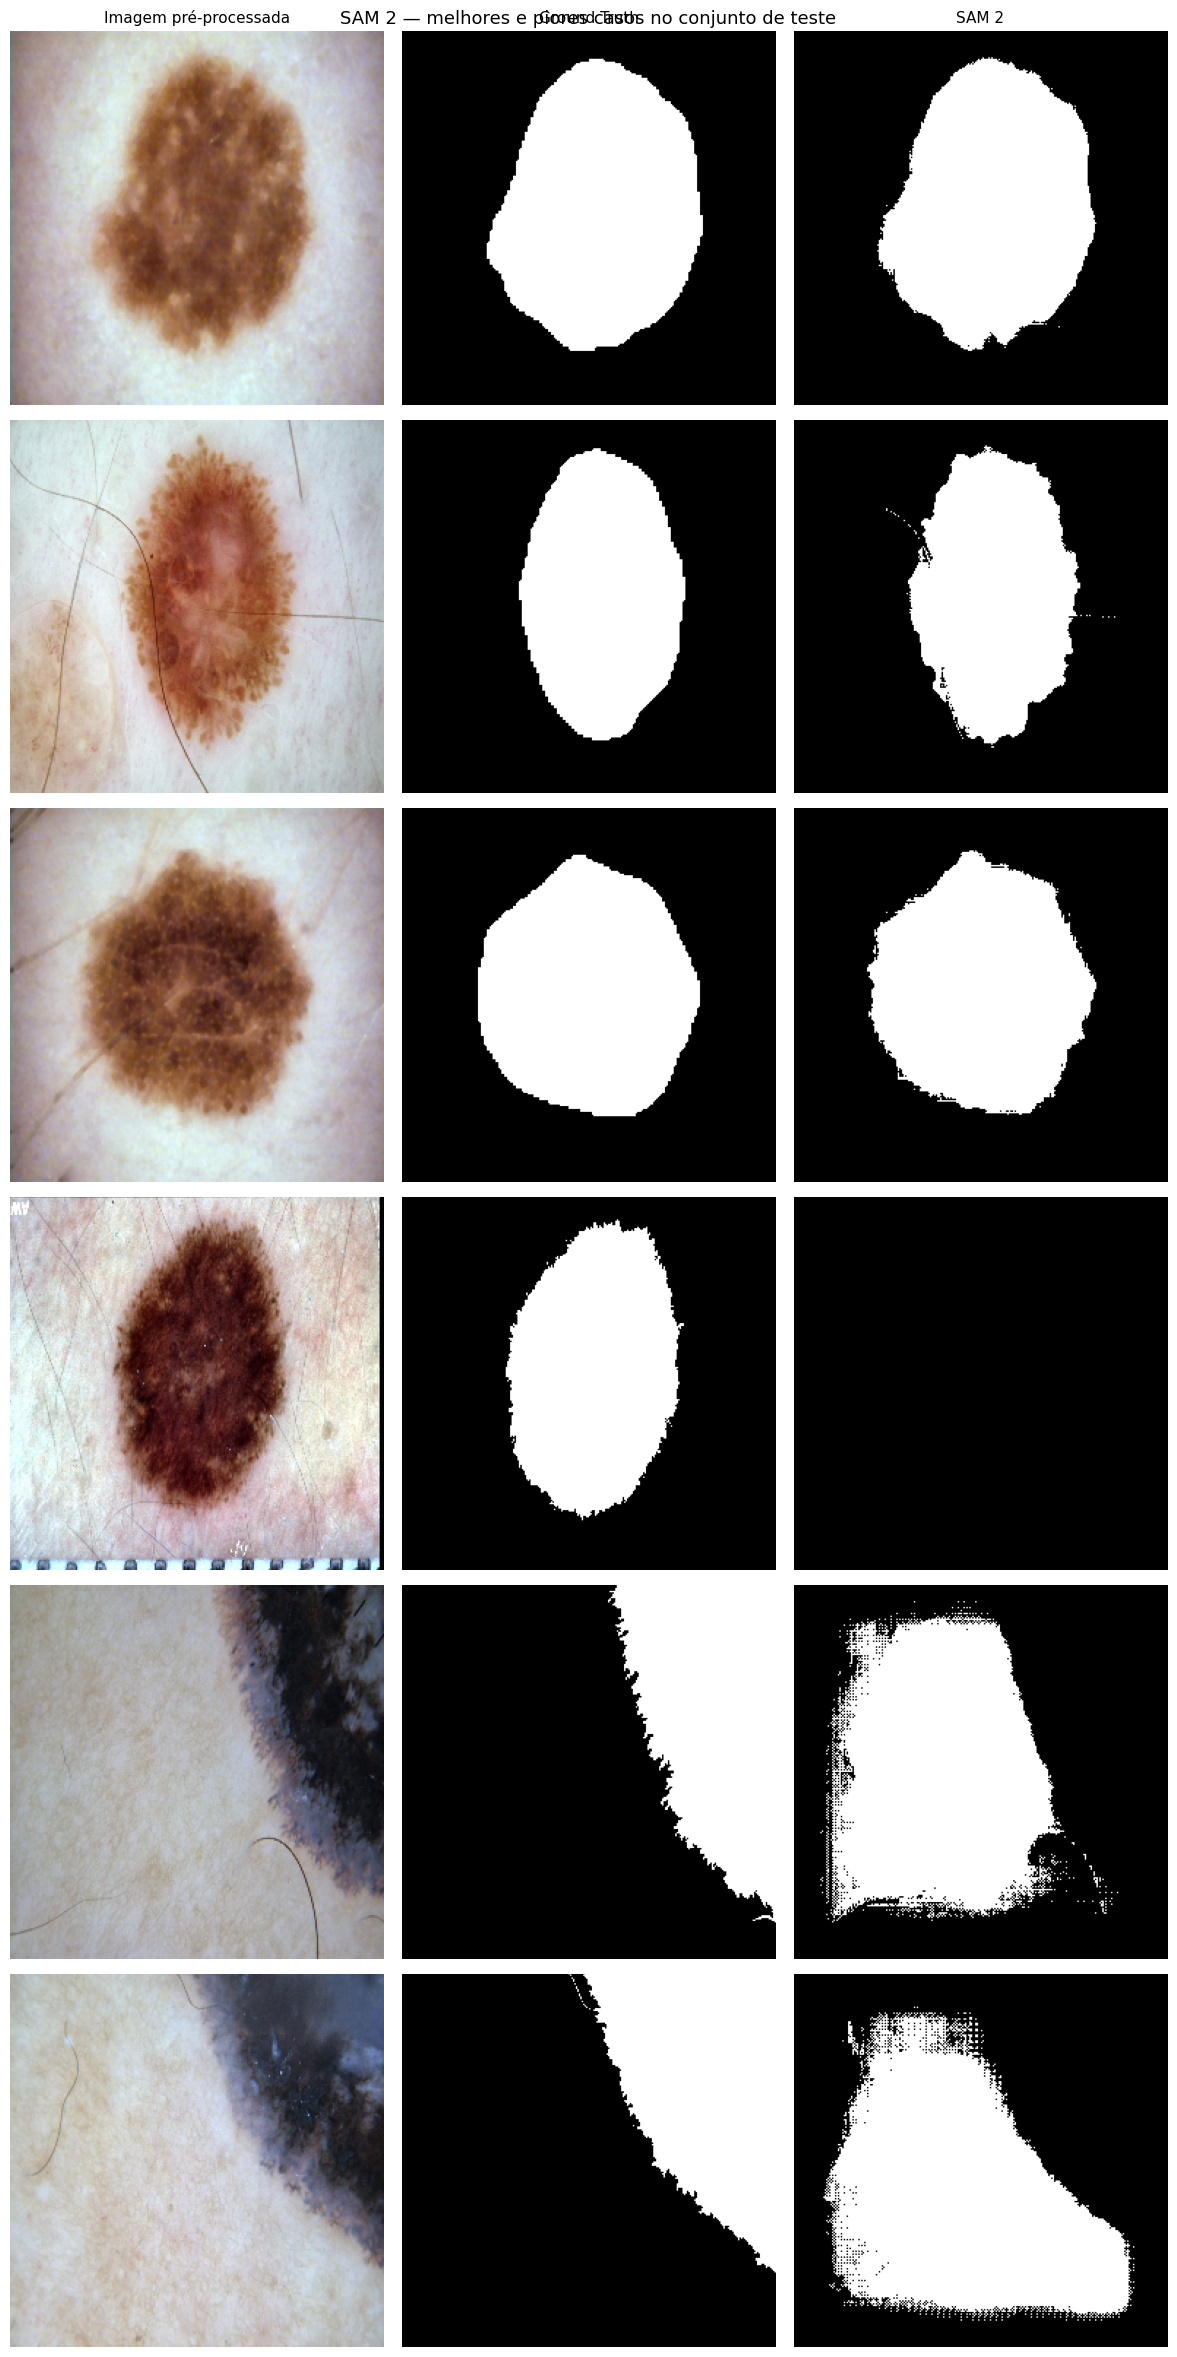

In [31]:
import random

# 3 melhores e 3 piores casos do SAM 2
best3  = df_sam2.nlargest(3,  'dice')['image'].tolist()
worst3 = df_sam2.nsmallest(3, 'dice')['image'].tolist()
samples = best3 + worst3
labels  = ['Melhor 1', 'Melhor 2', 'Melhor 3', 'Pior 1', 'Pior 2', 'Pior 3']

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
fig.suptitle('SAM 2 — melhores e piores casos no conjunto de teste', fontsize=13)

for col, title in enumerate(['Imagem pré-processada', 'Ground Truth', 'SAM 2']):
    axes[0, col].set_title(title, fontsize=11)

for row, (stem, label) in enumerate(zip(samples, labels)):
    img_path  = INPUT_DIR / f'{stem}.png'
    mask_path = GT_DIR    / f'{stem}.png'

    img      = load_image(str(img_path))
    mask_raw = load_image(str(mask_path))
    pred     = segmenter.segment(img)

    if mask_raw.ndim == 3:
        mask_raw = mask_raw[..., 0]
    gt = resize(mask_raw, pred.shape, order=0,
                preserve_range=True, anti_aliasing=False).astype(np.uint8)

    dice_val = df_sam2[df_sam2['image'] == stem]['dice'].values[0]

    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_ylabel(f'{label}\nDice={dice_val:.3f}', fontsize=9)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(gt,   cmap='gray')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(pred, cmap='gray')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('../results/figures/sam2_qualitative.png', dpi=150)
plt.show()
